In [2]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd
import tqdm
import numpy as np
import os
import glob
import awkward as ak
import boost_histogram as bh
import mplhep
# !pip install pyarrow
# !pip install "pyarrow<21" --break-system-packages

In [3]:
fpaths = glob.glob("AnalysisZipFramework/submission/analysis_output/*.root")
print(f"found {len(fpaths)} files")

found 555 files


In [4]:
h_pz_2022 = bh.Histogram(bh.axis.Regular(100, 0, 7000))
h_pz_2023 = bh.Histogram(bh.axis.Regular(100, 0, 7000))
h_pz_2024_preCaloNu = bh.Histogram(bh.axis.Regular(100, 0, 7000))
h_pz_2024_inCaloNu = bh.Histogram(bh.axis.Regular(100, 0, 7000))
h_pz_2024_postCaloNu = bh.Histogram(bh.axis.Regular(100, 0, 7000))

run_range_2022 = [7733, 9188]
run_range_2023 = [10555, 11703]
run_range_2024_preCaloNu = [14593, 15838]
run_range_2024_inCaloNu = [15839, 16923]
run_range_2024_postCaloNu = [1694, 17230]


for file in tqdm.tqdm(fpaths):
    with uproot.open(file) as f:
        tree = f["nt"]
        pz = tree["LeadTrack_pz0"].array(library="np")
        run = int(os.path.basename(file).replace(".root", ""))

        if run_range_2022[0] <= run <= run_range_2022[1]:
            h_pz_2022.fill(pz)

        if run_range_2023[0] <= run <= run_range_2023[1]:
            h_pz_2023.fill(pz)

        if run_range_2024_preCaloNu[0] <= run <= run_range_2024_preCaloNu[1]:
            h_pz_2024_preCaloNu.fill(pz)

        if run_range_2024_inCaloNu[0] <= run <= run_range_2024_inCaloNu[1]:
            h_pz_2024_inCaloNu.fill(pz)

        if run_range_2024_postCaloNu[0] <= run <= run_range_2024_postCaloNu[1]:
            h_pz_2024_postCaloNu.fill(pz)


  3%|▎         | 19/555 [00:04<02:01,  4.42it/s]

100%|██████████| 555/555 [02:06<00:00,  4.40it/s]


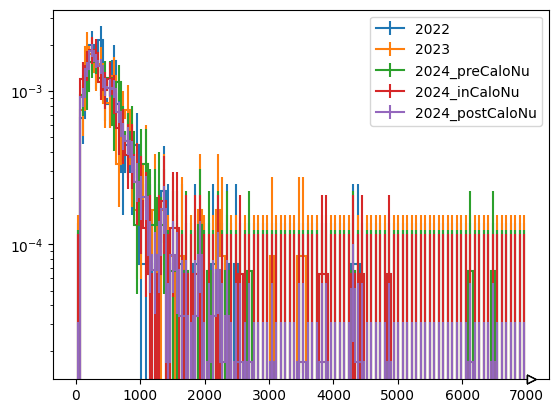

In [8]:
fig, ax = plt.subplots()
mplhep.histplot(h_pz_2022, label="2022", ax=ax, density=True)
mplhep.histplot(h_pz_2023, label="2023", ax=ax, density=True)
mplhep.histplot(h_pz_2024_preCaloNu, label="2024_preCaloNu", ax=ax, density=True)
mplhep.histplot(h_pz_2024_inCaloNu, label="2024_inCaloNu", ax=ax, density=True)
mplhep.histplot(h_pz_2024_postCaloNu, label="2024_postCaloNu", ax=ax, density=True)
ax.legend()
ax.set_yscale("log")

In [ ]:
h_pz_2022 = bh.Histogram(bh.axis.Regular(100, 0, 7000))
h_pz_2023 = bh.Histogram(bh.axis.Regular(100, 0, 7000))
h_pz_2024_preCaloNu = bh.Histogram(bh.axis.Regular(100, 0, 7000))
h_pz_2024_inCaloNu = bh.Histogram(bh.axis.Regular(100, 0, 7000))
h_pz_2024_postCaloNu = bh.Histogram(bh.axis.Regular(100, 0, 7000))

run_range_2022 = [7733, 9188]
run_range_2023 = [10555, 11703]
run_range_2024_preCaloNu = [14593, 15838]
run_range_2024_inCaloNu = [15839, 16923]
run_range_2024_postCaloNu = [1694, 17230]


for file in tqdm.tqdm(fpaths):
    with uproot.open(file) as f:
        tree = f["nt"]
        pz = tree["LeadTrack_pz0"].array(library="np")
        run = int(os.path.basename(file).replace(".root", ""))

        if run_range_2022[0] <= run <= run_range_2022[1]:
            h_pz_2022.fill(pz)

        if run_range_2023[0] <= run <= run_range_2023[1]:
            h_pz_2023.fill(pz)

        if run_range_2024_preCaloNu[0] <= run <= run_range_2024_preCaloNu[1]:
            h_pz_2024_preCaloNu.fill(pz)

        if run_range_2024_inCaloNu[0] <= run <= run_range_2024_inCaloNu[1]:
            h_pz_2024_inCaloNu.fill(pz)

        if run_range_2024_postCaloNu[0] <= run <= run_range_2024_postCaloNu[1]:
            h_pz_2024_postCaloNu.fill(pz)
